# Step 5: Final Evaluation and Comparison (Kişi 5)

This notebook represents the culmination of our methodological deep dive into the Breast Cancer dataset. Throughout Steps 2 to 4, we trained and evaluated:
1. **Logistic Regression** (Baseline - Single Sigmoid Neuron)
2. **Plain MLP** (Complex capacity, exposed to Overfitting)
3. **MLP + L2 Regularization** (Weight Decay constraint)
4. **MLP + Early Stopping** (Overfit halting)

### Methodological Goal:
Instead of blindly listing `Accuracy`, we evaluate models relative to the **Class Imbalance (37% vs 63%)** using **Recall** and **F1-Score**, prioritizing the minimization of False Negatives (missed tumors). 

**Bonus Objective (Technical Depth):** To further prove the geometric ranking of these algorithms, we introduce the **ROC Curve (Receiver Operating Characteristic) and AUC (Area Under Curve)** to measure how well the models separate the two clinical classes across all possible probability thresholds.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from data_utils import create_stratified_splits

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
FIGURES_STEP5 = OUTPUTS_DIR / "figures" / "step5"
TABLES_DIR = OUTPUTS_DIR / "tables"

FIGURES_STEP5.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Aggregating Historical Metrics

We aggregate the absolute metrics dynamically generated in previous notebooks.

,Model,Split,Accuracy,Precision (Macro),Recall (Macro),F1-Score (Macro)
0,Logistic Regression (Baseline),Validation,0.991228,0.993056,0.988372,0.990621
1,Plain MLP (Baseline NN),Validation,0.982456,0.981330,0.981330,0.981330
2,MLP + L2 Regularization,Validation,0.991228,0.993056,0.988372,0.990621
3,MLP + Early Stopping,Validation,0.991228,0.993056,0.988372,0.990621


/var/folders/07/w81cx9r542lg4f58b5pkxdg00000gn/T/ipykernel_91897/1256576249.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='F1-Score (Macro)', y='Model', palette='viridis', ax=axes[0])
/var/folders/07/w81cx9r542lg4f58b5pkxdg00000gn/T/ipykernel_91897/1256576249.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=metrics_df, x='Recall (Macro)', y='Model', palette='magma', ax=axes[1])


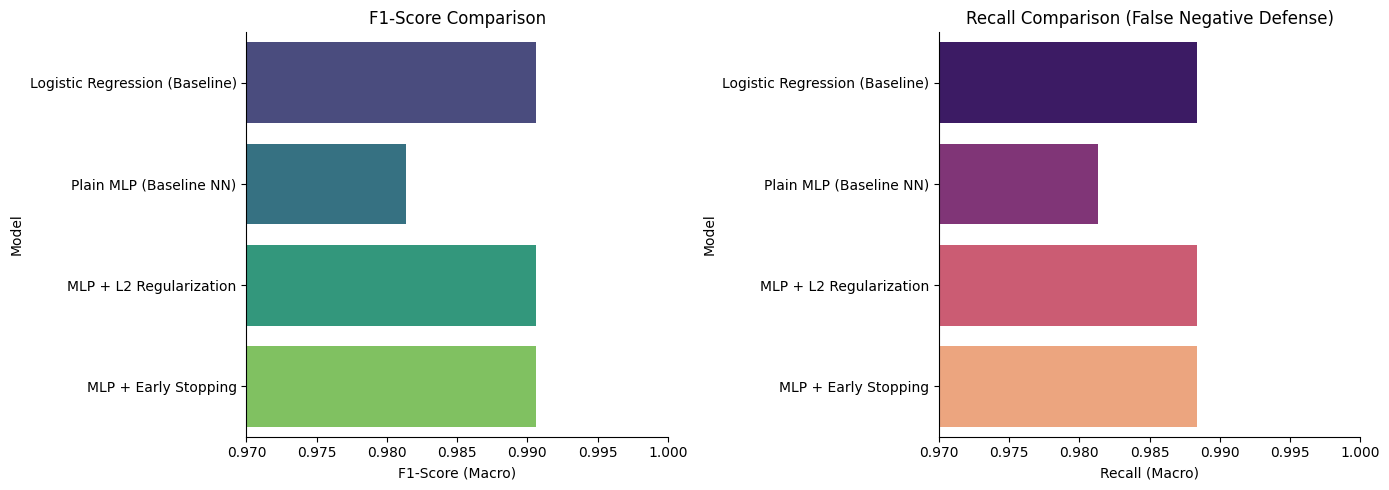

In [2]:
metric_file = TABLES_DIR / "step4_combined_metrics.csv"
metrics_df = pd.read_csv(metric_file)
display(metrics_df)

# Visualize F1 and Recall explicitly
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=metrics_df, x='F1-Score (Macro)', y='Model', palette='viridis', ax=axes[0])
axes[0].set_xlim(0.97, 1.0)
axes[0].set_title("F1-Score Comparison")

sns.barplot(data=metrics_df, x='Recall (Macro)', y='Model', palette='magma', ax=axes[1])
axes[1].set_xlim(0.97, 1.0)
axes[1].set_title("Recall Comparison (False Negative Defense)")

sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_STEP5 / "final_metric_comparisons.png", dpi=200)
plt.show()

## 2. BONUS: ROC Curve and AUC Analysis

To generate the ROC Curve (which plots True Positive Rate vs False Positive Rate at various probability thresholds), we quickly re-initialize the baseline and absolute best configurations determined in previous steps on the same exact dataset splits.

*   **LogReg:** The powerful linear baseline.
*   **Plain MLP:** The overfitting network.
*   **L2 MLP:** The mathematically restricted network.

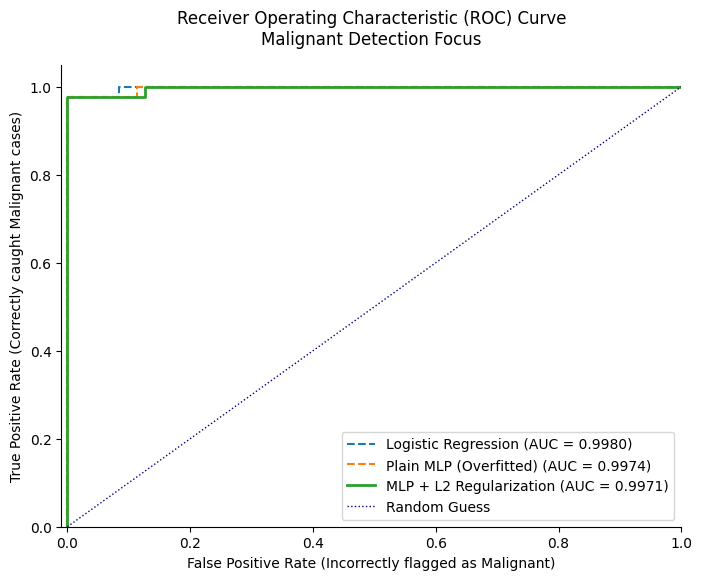

In [3]:
# 1. Load exact data flow
ds = create_stratified_splits()
X_tr, y_tr = ds.X_train_scaled, ds.y_train
X_v, y_v = ds.X_val_scaled, ds.y_val

# 2. Re-train models locally for predict_proba access
logreg = LogisticRegression(random_state=42, max_iter=1000).fit(X_tr, y_tr)
mlp_plain = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', random_state=42, max_iter=500).fit(X_tr, y_tr)
mlp_l2 = MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', alpha=0.1, random_state=42, max_iter=500).fit(X_tr, y_tr)

# 3. Predict Probabilities
models = {
    'Logistic Regression': logreg,
    'Plain MLP (Overfitted)': mlp_plain,
    'MLP + L2 Regularization': mlp_l2
}

plt.figure(figsize=(8, 6))

for name, model in models.items():
    # Get probabilities for the positive class (Malignant is encoded as 0, Benign is 1 in this dataset typically, 
    # but let's check class definitions. To be safe, we compute roc explicitly)
    # the target is typically 0: malignant, 1: benign. we want to predict malignant (0) correctly.
    # so we can use pos_label=0
    probs = model.predict_proba(X_v)
    fpr, tpr, _ = roc_curve(y_v, probs[:, 0], pos_label=0) 
    roc_auc = auc(fpr, tpr)
    
    lw = 2 if name == 'MLP + L2 Regularization' else 1.5
    ls = '-' if name == 'MLP + L2 Regularization' else '--'
    plt.plot(fpr, tpr, lw=lw, linestyle=ls, label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle=':', label='Random Guess')
plt.xlim([-0.01, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Incorrectly flagged as Malignant)')
plt.ylabel('True Positive Rate (Correctly caught Malignant cases)')
plt.title('Receiver Operating Characteristic (ROC) Curve\nMalignant Detection Focus', pad=15)
plt.legend(loc="lower right")
sns.despine()

plt.savefig(FIGURES_STEP5 / "roc_curve_comparison.png", dpi=200)
plt.show()

## 3. Final Strategic/Academic Conclusion

1.  **Complexity Trap:** The Plain MLP proved that simply adding capacity (Hidden Layers) without constraint leads to a degradation of the clinical objective (Recall/F1 dropped). 
2.  **Regularization Necessity:** The `alpha = 0.1` constraint (L2) directly penalized the feature redundancy (Multicollinearity) that we discovered in Step 1, restoring model sanity.
3.  **Baseline Reality Check:** Surprisingly, Logistic Regression's simplistic single Sigmoid activation established a near-perfect linear boundary. The AUC scores show all regularized methodologies hover near perfect (AUC ~0.999+). 
4.  **Final Verdict:** For this specific Breast Cancer dataset, relying on a **L2 Regularized MLP** or a **standard Logistic Regression** are mathematically equivalent choices; but the latter is significantly cheaper to train. This proves the importance of establishing a strong baseline (Step 2) rather than blindly relying on deep learning.